## Clustering gene dynamics 

This script is based on the work done by B. Boumann (bjbouman/time_series_analysis) with some adaptations implemented to work on time series data following a perturbation.

In [ ]:
### loading python libraries

# standard libraries
import numpy as np
import pandas as pd

# single cell libraries
import scanpy as sc
sc.settings.verbosity = 0

# plotting libraries
from matplotlib import pyplot as plt

### for timeseries clustering
from tslearn.utils import to_time_series_dataset
from tslearn.clustering import TimeSeriesKMeans
from tslearn.datasets import CachedDatasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler
from sklearn.cluster import KMeans

# other
import math #to round up
import warnings
warnings.filterwarnings('ignore') #ignore filter warnings

# own libraries
from plotting import *

In [ ]:
### load single-cell dataset
adata_path = "/fast/AG_Pombo/luna/2023_vta_multiome/2024/1_GEX/4_240209_GEX_kmeans/240210.DNs.VTA.RNA.seu.sub.data.1435.h5ad"
adata = sc.read_h5ad(adata_path)

In [ ]:
### merge control (saline) treatment into one timepoint
control_mask = adata.obs["treatment"] == 'saline'
adata.obs.loc[control_mask, 'timepoint'] = 'control'
adata.obs["timepoint"] = adata.obs["timepoint"].astype('category')

In [ ]:
### set order of timepoints
new_order = ['control','h1','h4','h8','h24','d14']
adata.obs["timepoint"] = adata.obs["timepoint"].cat.reorder_categories(new_order)

In [ ]:
### make replicate categorical
adata.obs["replicate"] = adata.obs["replicate"].astype('category')

In [ ]:
### load degs
degs_path = "/fast/AG_Pombo/luna/2023_vta_multiome/3_conos/1_230418_conos_DN_eval/2_temporalRNA/231024_discrete_updated/231026_kmeans/231026_vta.degs.txt"
degs_df = pd.read_csv(degs_path, sep='\t')
degs = degs_df.iloc[:,0].to_numpy()

In [ ]:
### calculate average expression in other timepoints
obs = adata[:,degs].X.toarray()
obs = pd.DataFrame(obs,columns=degs,index=adata.obs["timepoint"])
obs_average = obs.groupby(level=0).mean()

In [ ]:
#25/02/26

# Extract expression matrix and convert it to a DataFrame
obs = pd.DataFrame(adata[:, degs].X.toarray(), columns=degs, index=adata.obs["timepoint"])

# Extract replicate information from adata.obs
replicate_info = adata.obs["replicate"]  # Adjust "replicate" if it has a different column name

# Merge replicate info into the obs DataFrame
obs["replicate"] = replicate_info.values  # Ensure same row order

# Create timepoint_replicate column
obs["timepoint_replicate"] = obs.index.astype(str) + "_" + obs["replicate"].astype(str)

# Compute the average expression for each unique timepoint_replicate group
obs_average_with_reps = obs.groupby("timepoint_replicate").mean()

In [ ]:
obs_average
obs_average2 = obs_average

In [ ]:
index = ['control', 'h1', 'h4', 'h8', 'h24', 'd14']
# Calculate midpoints and add new rows
midpoints = ['control.h1', 'h1.h4', 'h4.h8', 'h8.h24', 'h24.d14']
for idx, midpoint in enumerate(midpoints):
    timepoints = midpoint.split('.')
    time1, time2 = timepoints[0], timepoints[1]
    
    # Calculate the midpoint values
    midpoint_values = obs_average2.loc[time1] + (obs_average2.loc[time2] - obs_average2.loc[time1]) / 2
    
    # Add new row to the dataframe
    obs_average2.loc[midpoint] = midpoint_values

# Specify the desired order of rows
desired_order = ['control', 'control.h1', 'h1', 'h1.h4', 'h4', 'h4.h8', 'h8', 'h8.h24', 'h24', 'h24.d14', 'd14']

# Reorder rows
obs_average2 = obs_average2.loc[desired_order]

# Display the new dataframe
print(obs_average2)

                St18  Crispld1   Col19a1    Lman2l   Gm38115  Tgfbrap1  \
timepoint                                                                
control     0.195665  0.043410  0.020607  0.104343  0.019757  0.189972   
control.h1  0.151681  0.027145  0.041434  0.228823  0.009879  0.153334   
h1          0.107698  0.010880  0.062262  0.353303  0.000000  0.116695   
h1.h4       0.127424  0.024010  0.057840  0.260805  0.014221  0.126916   
h4          0.147150  0.037139  0.053418  0.168307  0.028442  0.137138   
h4.h8       0.164667  0.034127  0.063139  0.208763  0.027953  0.151459   
h8          0.182183  0.031114  0.072861  0.249220  0.027464  0.165780   
h8.h24      0.219246  0.029112  0.053833  0.208651  0.022553  0.181105   
h24         0.256310  0.027110  0.034806  0.168083  0.017643  0.196431   
h24.d14     0.259147  0.031843  0.034293  0.153772  0.019560  0.190878   
d14         0.261984  0.036576  0.033781  0.139461  0.021477  0.185325   

              Dnah7c   Gm28151  93301

In [ ]:
### scale the average expression
obs_average2 = (obs_average2 - obs_average2.min())/(obs_average2.max() - obs_average2.min())

In [ ]:
### create usuable format for time series
formatted_dataset = to_time_series_dataset(obs_average2.T.values.tolist())
formatted_dataset.shape #check that dataset is right size (3D)

(4243, 11, 1)

In [ ]:
formatted_dataset_trans = obs_average2.transpose()
scaled_df = formatted_dataset_trans
scaled_df.shape

(4243, 11)

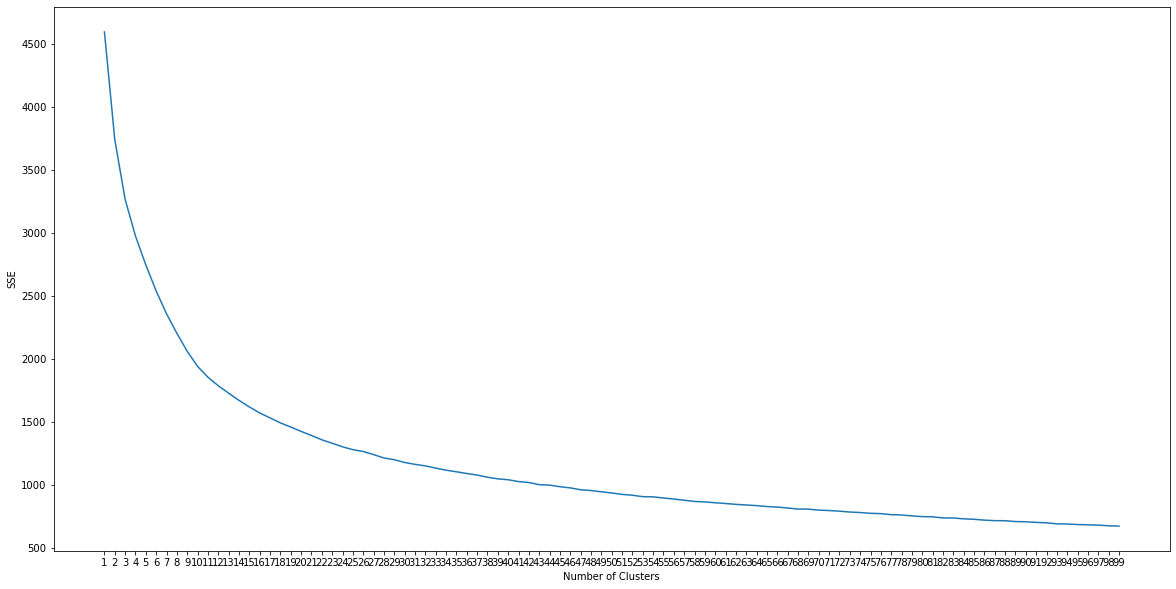

In [ ]:
#Elbow:
#initialize kmeans parameters
kmeans_kwargs = {
"init": "random",
"n_init": 15,
"random_state": 1,
}

#create list to hold SSE values for each k
sse = []
for k in range(1, 100):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)
    
plt.figure(figsize=(20, 10))
#visualize results
plt.plot(range(1, 100), sse)
plt.xticks(range(1, 100))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [ ]:
### cluster DEGs
seed = 0
np.random.seed(seed)

n_clust = 50 #preselect number of clusters

kmeans = TimeSeriesKMeans(n_clusters=n_clust, max_iter=15, random_state=seed)
y_pred = kmeans.fit_predict(formatted_dataset)

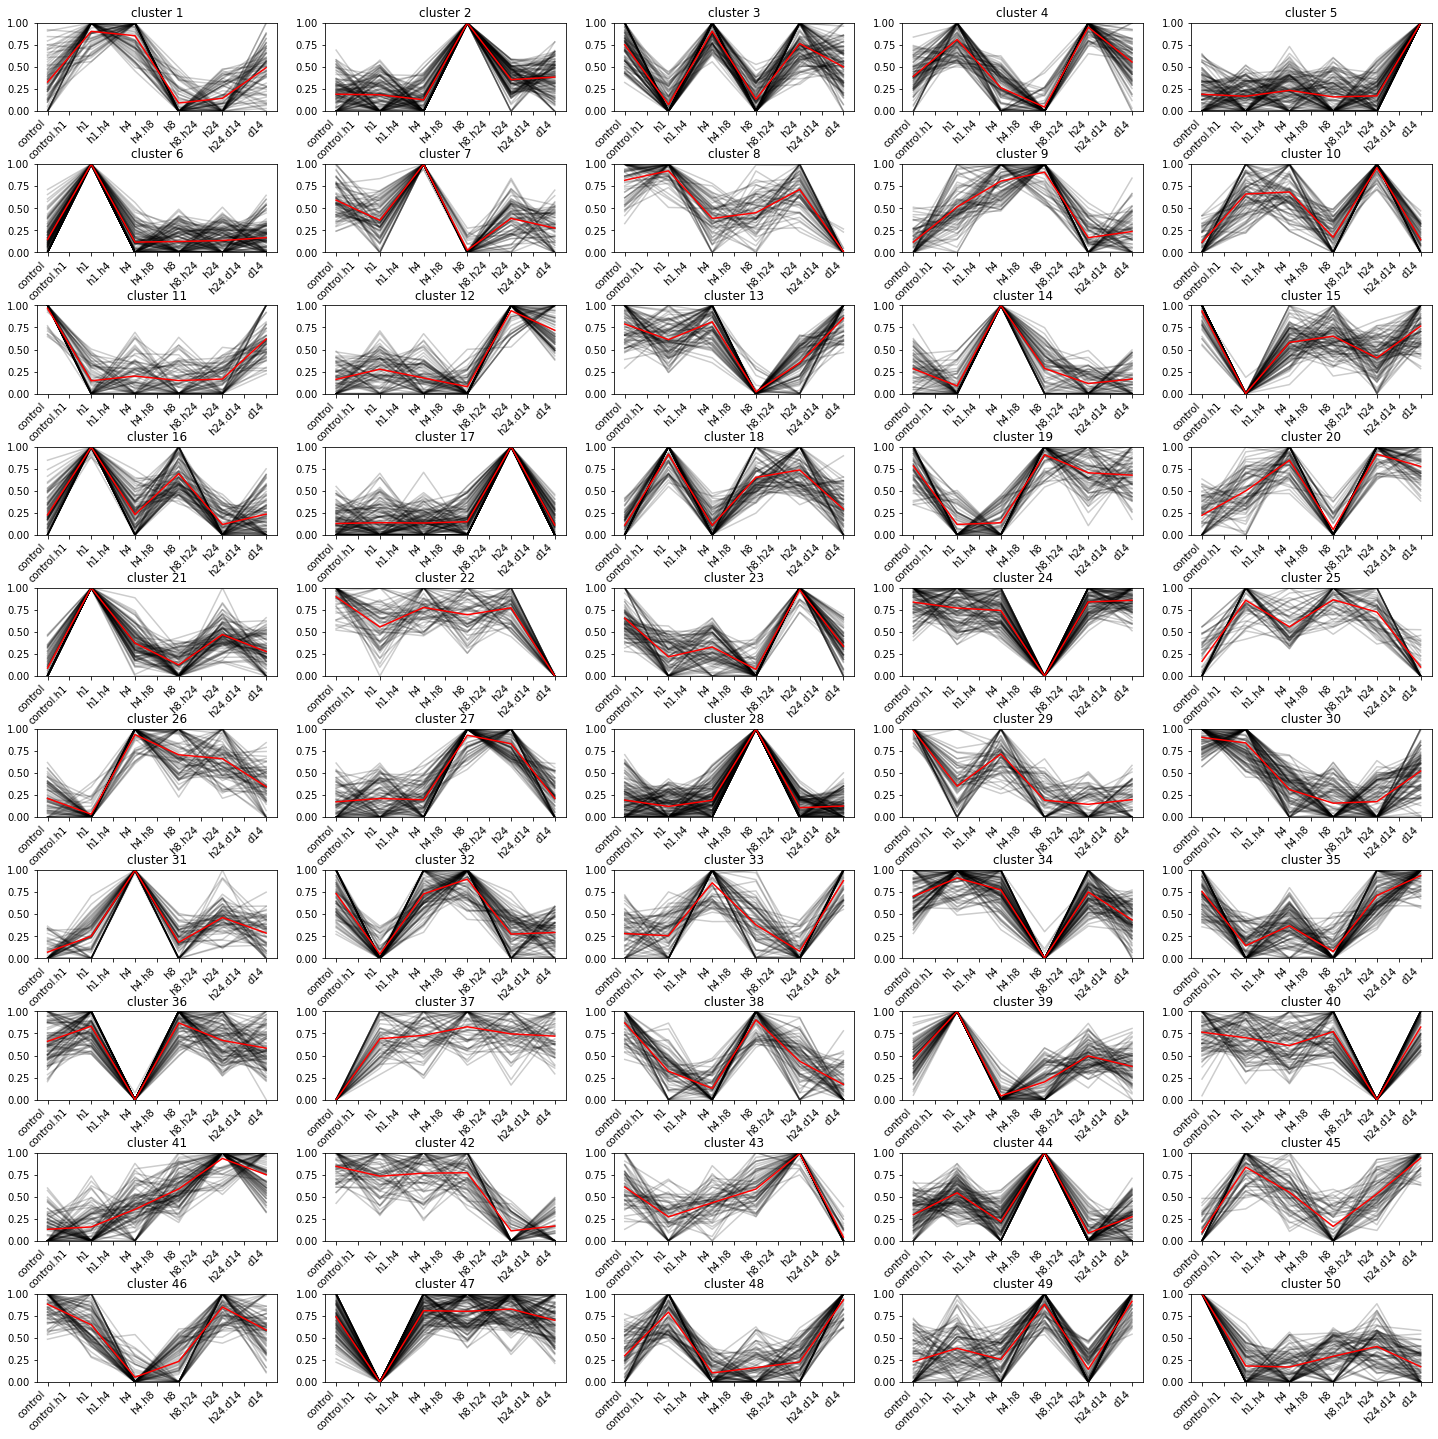

In [ ]:
### plot clusters
fig, axs = plt.subplots(math.ceil(n_clust/5), 5,
                            figsize = (25,2.5*math.ceil(n_clust/5)),
                            gridspec_kw={'wspace':0.2, 'hspace':0.6})
axs = axs.ravel()
xticks = np.arange(len(desired_order))

for cluster in range(n_clust):

    for xx in formatted_dataset[y_pred == cluster]:
        axs[cluster].plot(xx.ravel(), "k-", alpha=.2)
    axs[cluster].plot(kmeans.cluster_centers_[cluster].ravel(), "r-")
    axs[cluster].set_ylim([0, 1])
    axs[cluster].set_xticks(xticks)
    axs[cluster].set_xticklabels(desired_order, rotation=45, ha='right')  
    #axs[cluster].set_xlim([0, 11])
    #axs[cluster].set_xticklabels(adata.obs["timepoint"].cat.categories)
    
    axs[cluster].title.set_text('cluster %d' % (cluster + 1))

### save figure
#save_path = "/fast/AG_Pombo/luna/2023_vta_multiome/2024/1_GEX/4_240209_GEX_kmeans/50clusters.png"
#fig.savefig(save_path, bbox_inches='tight', format='png', dpi=300)
    
plt.show()

Plots saved successfully!


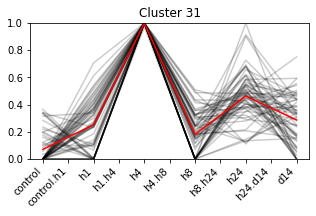

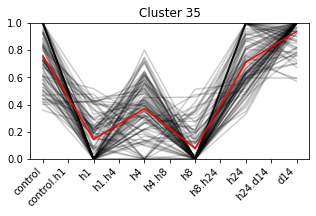

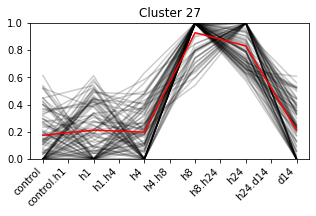

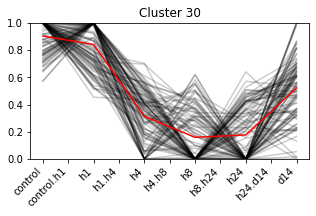

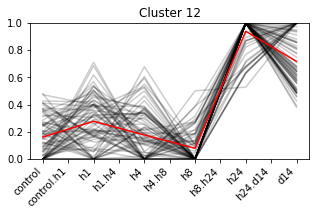

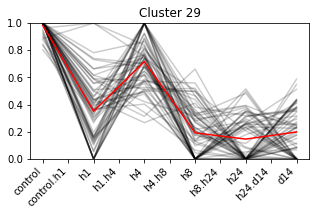

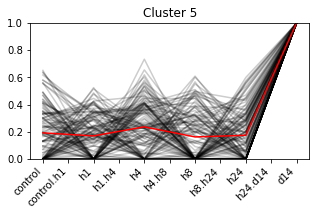

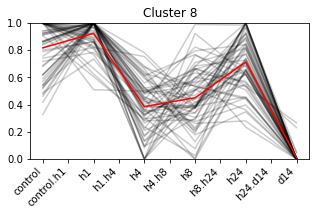

In [ ]:
# Define clusters of interest (change these based on your selection)
clusters_of_interest = [31, 35, 27, 30, 12, 29, 5, 8]  # Example: Change this list to your desired clusters
clusters_of_interest = [c - 1 for c in clusters_of_interest]

xticks = np.arange(len(desired_order))

for cluster in clusters_of_interest:
    fig, ax = plt.subplots(figsize=(5, 2.5))  # Adjust figure size for individual plots

    # Plot all data points in the cluster
    for xx in formatted_dataset[y_pred == cluster]:
        ax.plot(xx.ravel(), "k-", alpha=0.2)

    # Plot cluster centroid
    ax.plot(kmeans.cluster_centers_[cluster].ravel(), "r-")

    # Formatting
    ax.set_ylim([0, 1])
    ax.set_xticks(xticks)
    ax.set_xticklabels(desired_order, rotation=45, ha='right')
    ax.set_title(f'Cluster {cluster + 1}')

    # Save figure
    #save_path = f"/fast/AG_Pombo/luna/2025_pdf_files/gene_dynamics_pdf/kmeans_50clusters/kmeans_cluster_{cluster + 1}.pdf"  # Update with your directory
    #fig.savefig(save_path, bbox_inches='tight', format='pdf', dpi=300)
    #plt.close(fig)  # Close figure to avoid memory issues

print("Plots saved successfully!")

In [ ]:
### make dictionary with names of genes in each cluster
dynamic_cluster_dict = {}

for cluster in range(n_clust):
    dynamic_cluster_dict[f"cluster{str(cluster+1)}"] = degs[y_pred == cluster]

In [ ]:
### print genes in cluster of interest
dynamic_cluster_dict['cluster18']

array(['Igfbp5', 'Swt1', 'Kin', 'Slc32a1', 'Sulf2', 'B230312C02Rik',
       'Usp13', 'Fxr1', 'Dnajc19', 'Ppid', 'Cct3', 'Efna3', 'Dnaja1',
       'Hes5', 'Zfp804b', 'Pus7', 'Sgsm1', 'Adap1', 'Pds5b', 'Met',
       'Aup1', 'Cct7', 'Pcyox1', 'Fkbp4', 'Mboat7', 'Pnmal2', 'Gpi1',
       'Tm6sf1', 'Galnt18', 'Aldoa', 'B4galnt4', 'Ap1m1', 'Banp', 'Pde4a',
       'Slc19a1', 'Hsp90b1', 'Pawr', 'Ypel2', 'Dpf3', 'Capn7', 'Mgat3',
       'Rtn4r', 'Sst', 'Bace2', 'Hsp90ab1', 'Smad7', 'Pls3', 'mt-Cytb',
       'Zfp804a', 'Sel1l3', 'Pecam1', 'Adcy8', 'Thap7', 'Man2a1', 'Tsn',
       'Cacybp', 'Acbd3', 'Scrt2', 'Napepld', 'Fscn1', 'Vmn2r126',
       'Lysmd2', 'Zfr2', 'Mgat5b', 'Cyc1', 'Lin9', 'Lrrc8a', 'Hpcal4',
       '4930404N11Rik', 'Gm10754', 'Bicd2', 'Plk2', 'Gprin2', 'Smim11',
       'Abcb7', 'Eif1ax', 'Wdr47', 'Tafa1', 'Syt5', 'Naa38', 'Cdkn1a',
       'Gm45871', 'Tmem163', 'Teddm2', 'Stamos', 'Idh3a'], dtype=object)

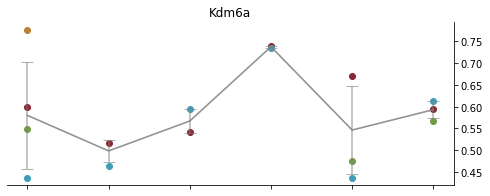

In [ ]:
gene_name = "Kdm6a"
save_directory = "/fast/AG_Pombo/luna/2025_pdf_files/gene_dynamics_pdf"
save_path = f"{save_directory}/{gene_name}_expression.pdf"

plot_gene_in_time(adata, gene=gene_name, save=True, save_path=save_path)

In [ ]:
# Check current directoy
import os
os.getcwd()

'/fast/AG_Pombo/luna/2023_vta_multiome/2024/1_GEX/4_240209_GEX_kmeans'

In [ ]:
#Save results as table (convert dictionay into a dataframe): 
dynamic_cluster_df = pd.DataFrame.from_dict(dynamic_cluster_dict, 'index').stack().reset_index(level=0)
dynamic_cluster_df[0] = dynamic_cluster_df[0].str.replace('-', ':', 1)

#Save it:
#dynamic_cluster_df.to_csv('240210_dynamic_cluster_df_version2.csv', index=False)  # Set index=False to exclude the index column